# Wind Speed and Gust as Supporting Wind-Comfort Indicators

**Research Question:** *How closely are wind speed and gust related, and can sudden increases in gust strength signal unstable or changing weather conditions?*

This section contributes one part of the group analysis: whether `wind_speed` and `gust` can support clearer public guidance on outdoor comfort and changing conditions. The aim is to define the useful role of wind indicators without overstating them against the other project indicators such as UV, rainfall, temperature, and humidity.


## 1. Client Context and Variables

The client needs weather indicators that the public can interpret quickly. For wind, the key question is whether `gust` adds useful public-facing information beyond average `wind_speed`, or whether it should remain a supporting detail.

### Variables used

| Variable | Unit | Role in this analysis |
|---|---|---|
| `wind_speed` | m/s | Baseline wind condition |
| `gust` | m/s | Short-burst wind strength |
| `precipitation_rate` | mm/h | Check against wet-weather conditions |
| `pressure` | hPa | Supporting context for broader weather change |

`gust_factor = gust / wind_speed` is added where `wind_speed > 0` to show how much stronger a short burst is than the average wind. This is useful for deciding whether gust should appear in public guidance as a wind-comfort cue.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'malaysia_weather_cleaned.csv'
CSV_TITLE_ROWS = 1


In [2]:
def load_cleaned_weather(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=CSV_TITLE_ROWS)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    return df


def prepare_weather_subset(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['datetime', 'pressure', 'wind_speed', 'gust', 'precipitation_rate']
    weather = df[cols].copy()

    weather = weather.dropna(subset=['datetime', 'wind_speed', 'gust']).copy()
    weather = weather[(weather['wind_speed'] >= 0) & (weather['gust'] >= 0)].copy()

    weather['wet_weather'] = weather['precipitation_rate'].fillna(0) > 0
    weather['gust_diff'] = weather['gust'] - weather['wind_speed']
    weather['gust_factor'] = np.where(weather['wind_speed'] > 0, weather['gust'] / weather['wind_speed'], np.nan)
    weather['high_gust'] = weather['gust'] >= weather['gust'].quantile(0.9)
    weather['high_gust_factor'] = weather['gust_factor'] >= weather['gust_factor'].quantile(0.9)

    return weather

raw_df = load_cleaned_weather(DATA_PATH)
analysis_df = prepare_weather_subset(raw_df)

analysis_share = len(analysis_df) / len(raw_df)


## 2. Preparing Wind Indicators

Only observations with usable `datetime`, `wind_speed`, and `gust` values are used. Two simple indicators are created for client interpretation:

- `gust_diff`: absolute increase from average wind to peak gust
- `gust_factor`: relative increase from average wind to peak gust


In [3]:
cleaning_summary = pd.DataFrame({
    'metric': [
        'Cleaned dataset rows',
        'Usable wind/gust rows',
        'Share kept for this section (%)',
        'Wet-weather rows in wind/gust subset',
        'Rows with valid gust_factor',
        'Median wind_speed (m/s)',
        'Median gust (m/s)',
        'Median gust_factor'
    ],
    'value': [
        len(raw_df),
        len(analysis_df),
        analysis_share * 100,
        int(analysis_df['wet_weather'].sum()),
        int(analysis_df['gust_factor'].notna().sum()),
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median(),
        analysis_df['gust_factor'].median(),
    ]
})

display(cleaning_summary)


,metric,value
0,Cleaned dataset rows,"51,693.000"
1,Usable wind/gust rows,"44,191.000"
2,Share kept for this section (%),85.487
3,Wet-weather rows in wind/gust subset,"2,240.000"
4,Rows with valid gust_factor,"29,207.000"
5,Median wind_speed (m/s),0.800
6,Median gust (m/s),1.600
7,Median gust_factor,1.545


### Section Conclusion

The analysis keeps a usable wind/gust subset and creates interpretable indicators for short-burst wind strength. This is enough for communication guidance, without turning the section into a forecasting model.


## 3. Wind Speed and Gust Move Together

The first check is whether `gust` behaves like a sharper version of the same wind pattern, or whether it provides a separate signal.


,metric,value
0,Correlation between wind_speed and gust,0.934
1,Proportion of rows where gust >= wind_speed,1.000
2,Median wind_speed (m/s),0.800
3,Median gust (m/s),1.600


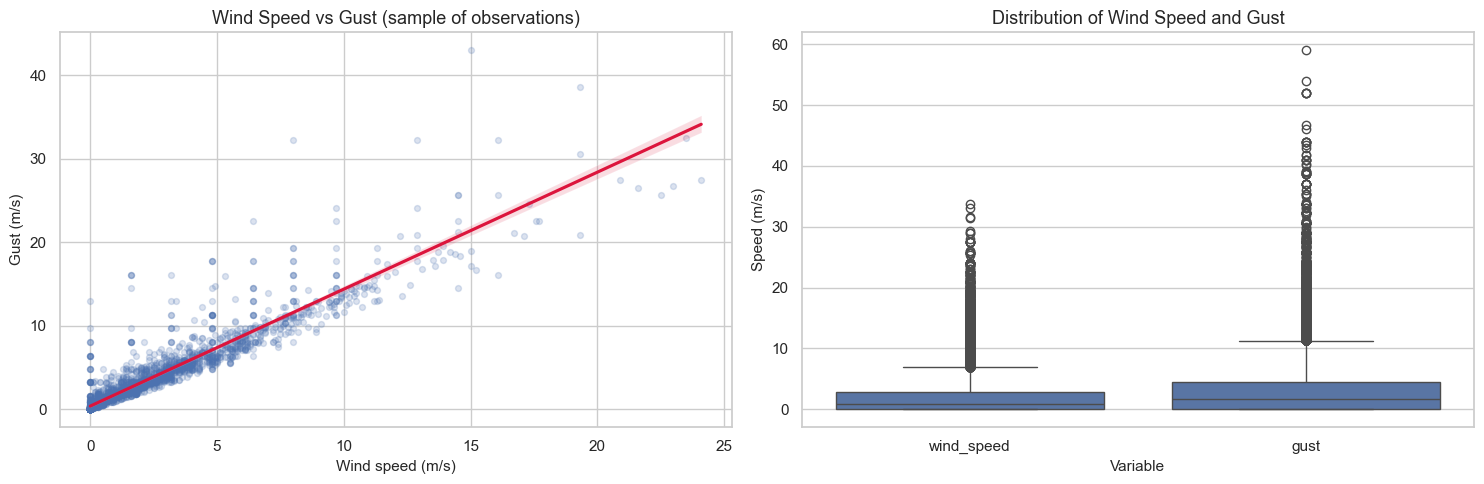

In [4]:
correlation = analysis_df['wind_speed'].corr(analysis_df['gust'])
prop_gust_ge_wind = (analysis_df['gust'] >= analysis_df['wind_speed']).mean()
relationship_summary = pd.DataFrame({
    'metric': [
        'Correlation between wind_speed and gust',
        'Proportion of rows where gust >= wind_speed',
        'Median wind_speed (m/s)',
        'Median gust (m/s)'
    ],
    'value': [
        correlation,
        prop_gust_ge_wind,
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median()
    ]
})

display(relationship_summary)

# Use a sample so the scatter plot stays readable in the notebook.
sample_df = analysis_df.sample(n=min(3000, len(analysis_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    data=sample_df,
    x='wind_speed',
    y='gust',
    scatter_kws={'alpha': 0.2, 's': 18},
    line_kws={'color': 'crimson'},
    ax=axes[0]
)
axes[0].set_title('Wind Speed vs Gust (sample of observations)')
axes[0].set_xlabel('Wind speed (m/s)')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(
    data=analysis_df[['wind_speed', 'gust']].melt(var_name='variable', value_name='value'),
    x='variable',
    y='value',
    ax=axes[1]
)
axes[1].set_title('Distribution of Wind Speed and Gust')
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Speed (m/s)')

plt.tight_layout()
plt.show()

### Section Conclusion

`wind_speed` and `gust` are closely related, with a correlation of about **0.934**. Gust is greater than or equal to average wind in the valid observations used here.

For the client, `gust` should be read as an extension of wind conditions, not as an independent weather-change indicator.


## 4. Gust Adds a Public Feel Signal

The communication value of `gust` depends on whether it meaningfully changes how wind feels outdoors.

`gust_diff` and `gust_factor` show how much stronger short bursts are than average wind conditions.


,metric,value
0,Median gust_diff (m/s),0.600
1,Mean gust_diff (m/s),1.165
2,Median gust_factor,1.545
3,Mean gust_factor,1.943
4,90th percentile gust_factor,3.000


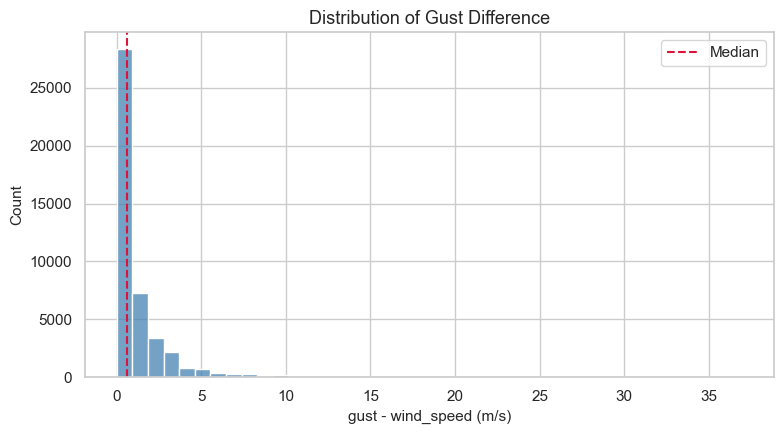

In [5]:
gust_strength_summary = pd.DataFrame({
    'metric': [
        'Median gust_diff (m/s)',
        'Mean gust_diff (m/s)',
        'Median gust_factor',
        'Mean gust_factor',
        '90th percentile gust_factor'
    ],
    'value': [
        analysis_df['gust_diff'].median(),
        analysis_df['gust_diff'].mean(),
        analysis_df['gust_factor'].median(),
        analysis_df['gust_factor'].mean(),
        analysis_df['gust_factor'].quantile(0.9)
    ]
})

display(gust_strength_summary)

plt.figure(figsize=(8, 4.5))
sns.histplot(analysis_df['gust_diff'], bins=40, color='steelblue')
plt.axvline(analysis_df['gust_diff'].median(), color='crimson', linestyle='--', label='Median')
plt.title('Distribution of Gust Difference')
plt.xlabel('gust - wind_speed (m/s)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### Section Conclusion

The median `gust_diff` is about **0.6 m/s**, while the median `gust_factor` is about **1.55**. In practical terms, this means gust is often about **55% stronger** than the average wind reading when wind is present.

This gives `gust` a clear but limited client use: it can add a short-burst wind caution when average wind alone may understate how conditions feel outdoors.


## 5. Gust Is Weak Rainfall Evidence

This check tests whether stronger gust behaviour is also a useful rainfall signal.


wind_speed         gust        gust_factor         pressure  \
                  mean median  mean median        mean median      mean   
wet_weather                                                               
False            1.969  0.800 3.122  1.600       1.940  1.545 1,010.765   
True             2.213  1.000 3.612  1.800       2.006  1.556 1,010.447   

                      precipitation_rate         
               median               mean median  
wet_weather                                      
False       1,011.180              0.000  0.000  
True        1,010.670              7.142  1.800

,indicator_rule,wet_weather_rate
0,All observations,0.051
1,Top 10% gust: gust >= 8.4 m/s,0.064
2,Top 10% gust factor: gust_factor >= 3.0,0.060


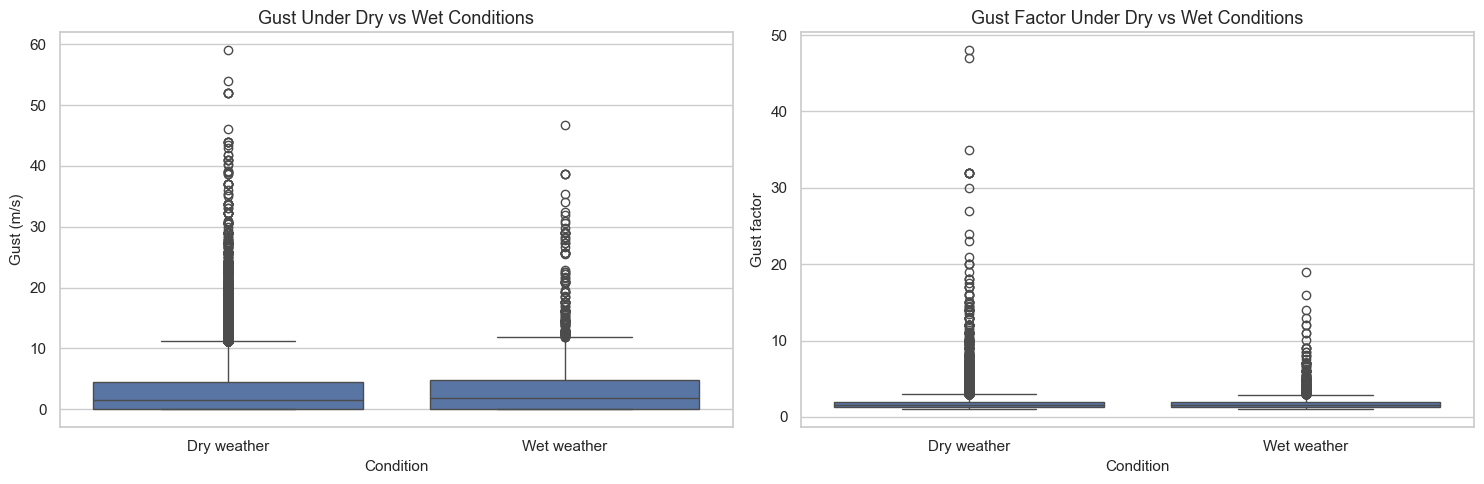

In [6]:
condition_labels = np.where(analysis_df['wet_weather'], 'Wet weather', 'Dry weather')
plot_df = analysis_df.assign(condition=condition_labels)

wet_summary = (
    analysis_df.groupby('wet_weather')[['wind_speed', 'gust', 'gust_factor', 'pressure', 'precipitation_rate']]
    .agg(['mean', 'median'])
    .round(3)
)

gust_p90 = analysis_df['gust'].quantile(0.9)
gust_factor_p90 = analysis_df['gust_factor'].quantile(0.9)

top_decile_rates = pd.DataFrame({
    'indicator_rule': [
        'All observations',
        f'Top 10% gust: gust >= {gust_p90:.1f} m/s',
        f'Top 10% gust factor: gust_factor >= {gust_factor_p90:.1f}'
    ],
    'wet_weather_rate': [
        analysis_df['wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust'], 'wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust_factor'], 'wet_weather'].mean()
    ]
})

display(wet_summary)
display(top_decile_rates)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_df, x='condition', y='gust', ax=axes[0])
axes[0].set_title('Gust Under Dry vs Wet Conditions')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(data=plot_df[plot_df['gust_factor'].notna()], x='condition', y='gust_factor', ax=axes[1])
axes[1].set_title('Gust Factor Under Dry vs Wet Conditions')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Gust factor')

plt.tight_layout()
plt.show()

### Section Conclusion

Wet-weather observations do show slightly stronger gust behaviour, but the increase is **modest rather than dramatic**. The wet-weather rate is about **5.1%** overall, rising only to about **6.4%** when `gust` is in the top 10% and about **6.0%** when `gust_factor` is in the top 10%.

For the client, `gust` should not be presented as a direct rainfall warning. It is better used as a supporting wind-comfort cue, while rainfall messages should be led by rainfall indicators.


## 6. Contribution to the Group Conclusion

### Wind section takeaway

This section should contribute one focused point to the overall conclusion: **gust is useful as a secondary wind-comfort indicator, not as a headline indicator for rainfall or broad weather change**.

### Evidence to carry forward

- `wind_speed` and `gust` move together strongly (`r` about **0.934**), so gust should be paired with wind speed rather than treated as a separate signal.
- Gusts are often noticeably stronger than average wind (`median gust_factor` about **1.55**), so they can help explain why outdoor conditions may feel more sudden or unstable.
- Strong gust behaviour only slightly increases the wet-weather rate, so gust alone is too weak for rainfall communication.

### Client-facing recommendation for integration

Use `wind_speed` to describe baseline wind comfort, and add `gust` when short bursts may make conditions feel more exposed or unstable for outdoor users. Do not use gust alone as evidence of rainfall; combine it with the group's rainfall and pressure findings when discussing broader weather change.

### Suggested wording for the final group conclusion

"Wind speed should describe baseline outdoor wind comfort, while gust can add a short-burst caution. Gust should remain a supporting indicator and should not be used by itself to communicate rainfall risk."

### Limitation

This notebook uses cleaned observational weather data rather than a forecasting model, so the results support **communication guidance** rather than formal prediction. Stronger predictive claims would require a more explicit event-based forecasting setup.
